In [1]:
from collections import defaultdict
import re

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split

import numpy as np
import pandas as pd

import torchvision.transforms as transforms
import torchvision

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from typing import Dict, List, Any
from tqdm.auto import tqdm

# Set style for better visualizations
sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

#### Загружаем MNIST

In [16]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Download full training dataset
full_train_dataset = torchvision.datasets.MNIST(
    root='../data',
    train=True,
    transform=transform,
    download=True
)

# Download test dataset
test_dataset = torchvision.datasets.MNIST(
    root='../data',
    train=False,
    transform=transform,
    download=True
)

# Split training data into train and validation (80-20 split)
train_size = int(0.85 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")

# Create data loaders
BATCH_SIZE = 64

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"\nNumber of batches:")
print(f"Train loader: {len(train_loader)} batches")
print(f"Validation loader: {len(val_loader)} batches")
print(f"Test loader: {len(test_loader)} batches")

Training samples: 51000
Validation samples: 9000
Test samples: 10000

Number of batches:
Train loader: 797 batches
Validation loader: 141 batches
Test loader: 157 batches


#### Понадобится позже

In [17]:
class SkipIdxDataloader():
    def __init__(self, loader, keep_ids):
        self.loader = loader
        self.keep_ids = keep_ids
        self.iterator = None
    
    def __iter__(self):
        self.iterator = iter(self.loader)
        return self
    
    def __next__(self):
        batch = next(self.iterator)
        data, targets = batch
        
        data_reshaped = data.reshape(data.shape[0], -1)
        data_selected = data_reshaped[:, self.keep_ids]

        return data_selected, targets

In [18]:
# pip install SToG
from SToG import BaseFeatureSelector

In [19]:
from dataclasses import dataclass

# for comfortability
@dataclass
class ClassifModelOutput:
    ce_loss : torch.Tensor = None
    regularization_loss : torch.Tensor = None
    loss : torch.Tensor = None
    logits : torch.Tensor = None

#### Rewrite STG layer to fix bag with mu and add selected feature counting

In [20]:
import math

class STGLayer(BaseFeatureSelector):
    """
    Stochastic Gates (STG) - Original implementation from Yamada et al. 2020.
    Uses Gaussian-based continuous relaxation of Bernoulli variables.
    
    Reference: "Learning Feature Sparse Principal Subspace" (Yamada et al., ICML 2020)
    UPD: add counting of selected features
    """
    
    def __init__(self, input_dim: int, sigma: float = 0.5, device: str = 'cpu'):
        super().__init__(input_dim, device)
        self.mu = nn.Parameter(torch.ones(input_dim)*0.5)
        self.sigma = sigma
        
        self._select_features_count = 0
        self._num_forwards = 0
        

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        self._num_forwards += 1
        """Apply stochastic gates to input features."""
        if self.training:
            eps = torch.randn_like(self.mu) * self.sigma
            z = self.mu + eps
            gates = torch.clamp(z, 0.0, 1.0)
            self._select_features_count += (z > 0).sum().detach().cpu().numpy().item()
        else:
            # At inference, use deterministic mean
            gates = torch.clamp(self.mu, 0.0, 1.0)
            self._select_features_count += (self.mu > 0).sum().detach().cpu().numpy().item()
        return x * gates.unsqueeze(0)

    def reset_counter(self):
        self._select_features_count = 0

    def get_select_features_mean(self):
        return self._select_features_count/self._num_forwards

    def regularization_loss(self) -> torch.Tensor:
        """Compute regularization: sum of probabilities of selection."""
        # P(z_d > 0) = 0.5 * (1 + erf(mu_d / (sigma * sqrt(2))))
        return torch.sum(0.5 * (1 + torch.erf(self.mu / (self.sigma * math.sqrt(2)))))

    def get_selection_probs(self) -> torch.Tensor:
        """Get selection probabilities for each feature."""
        return (0.5 * (1 + torch.erf(self.mu / (self.sigma * math.sqrt(2))))).detach()

#### Utilities to add layers before Linear and logging

In [21]:
class LinearFeatureSelectWrapper(nn.Module):
    def __init__(self, select_layer : BaseFeatureSelector, **linear_kwargs):
        super().__init__()
        self.select_layer = select_layer
        self.linear = nn.Linear(**linear_kwargs)
    def forward(self, x):
        return self.linear(self.select_layer(x))


def replace_linear_layers(model,
                          feature_selection_class,
                          pattern = "",
                          prefix = ""):
    """
    Recursively replace all nn.Linear layers with LinearWrapper
    
    Args:
        model: The PyTorch model
        linear_wrapper_class: Your custom wrapper class
    
    Returns:
        Modified model with LinearWrapper layers
    """
    for name, module in model.named_children():
        full_name = f"{prefix}.{name}" if prefix else name
        if isinstance(module, nn.Linear) and re.match(pattern, full_name):
            # Replace Linear with LinearWrapper
            wrapped_layer = LinearFeatureSelectWrapper(
                select_layer = feature_selection_class(module.in_features),
                in_features=module.in_features,
                out_features=module.out_features,
                bias=module.bias is not None
            )
            
            # Copy the weights and bias if they exist
            with torch.no_grad():
                wrapped_layer.linear.weight.copy_(module.weight)
                if module.bias is not None:
                    wrapped_layer.linear.bias.copy_(module.bias)
            
            # Replace the module
            setattr(model, name, wrapped_layer)

        else:
            # Recursively apply to child modules
            replace_linear_layers(module, feature_selection_class, pattern = pattern, prefix = full_name)
    
    return model

def calc_reg_loss(module):
    curr_sum = 0.0
    for name, module in module.named_children():
        if isinstance(module, BaseFeatureSelector):
            curr_sum += module.regularization_loss()
        else:
            curr_sum += calc_reg_loss(module)
    return curr_sum

def collect_feature_selection_metrics(model: nn.Module) -> Dict[str, float]:
    """
    Parse through the network and collect get_select_features_mean() from all BaseFeatureSelector instances.
    
    Args:
        model: PyTorch model containing BaseFeatureSelector layers
        
    Returns:
        Dictionary with layer names as keys and feature selection means as values
    """
    feature_selection_metrics = {}
    
    def recurse_and_collect(module: nn.Module, prefix: str = ''):
        for name, child in module.named_children():
            full_name = f"{prefix}.{name}" if prefix else name
            
            # Check if current module is an instance of BaseFeatureSelector
            if isinstance(child, BaseFeatureSelector):
                try:
                    # Call get_select_features_mean() and store result
                    mean_value = child.get_select_features_mean()
                    feature_selection_metrics[full_name] = mean_value
                except AttributeError:
                    print(f"Warning: {full_name} doesn't have get_select_features_mean() method")
                except Exception as e:
                    print(f"Error processing {full_name}: {e}")
            
            # Recursively check child modules
            recurse_and_collect(child, full_name)
    
    # Start recursion from root
    recurse_and_collect(model)
    
    return feature_selection_metrics

#### Main FeedForwardNetwork and Classification Wrapper

In [22]:
class FeedForwardNetwork(nn.Module):
    def __init__(self,
                 in_features : int,
                 hidden_dim : int,
                 out_features : int,
                 num_layers : int,
                 activation_class = nn.ReLU,
                 norm_class = nn.BatchNorm1d,
                 dropout : float = 0.15):
        super().__init__() 
        layers = []
        for i in range(num_layers):         
            in_feats = in_features if i == 0 else hidden_dim
            layers.append(
                nn.Sequential(
                   nn.Linear(in_feats, hidden_dim),
                   norm_class(hidden_dim),
                   activation_class(),
                   nn.Dropout(dropout)
                )
            )

        layers.append(nn.Linear(hidden_dim, out_features))
        
        self.model = nn.Sequential(
            *layers
        )


    def forward(self, x) -> torch.Tensor:
        if len(x.shape) > 2:
            x = x.reshape(x.shape[0], -1)
        return self.model(x)

def calc_reg_loss(module):
    curr_sum = 0.0
    for name, module in module.named_children():
        if isinstance(module, BaseFeatureSelector):
            curr_sum += module.regularization_loss()
        else:
            curr_sum += calc_reg_loss(module)
    return curr_sum 

class ClassificationFeatureSelectionWrapper(nn.Module):
    def __init__(self,
                 backbone : nn.Module, 
                 feature_selection_class = STGLayer,
                 lambda_coef : float = 0.01,
                 feature_selection_layers_substring : str = "",
                 criterion = nn.CrossEntropyLoss()):
        super().__init__()
        self.backbone = backbone
        self.criterion = criterion
        self.lambda_coef = lambda_coef
        replace_linear_layers(self.backbone,
                              feature_selection_class=feature_selection_class,
                              pattern=f".*{feature_selection_layers_substring}.*")

    def forward(self, X, y) -> ClassifModelOutput:
        logits = self.backbone(X)
        ce_loss = self.criterion(logits, y)
        reg_loss = calc_reg_loss(self.backbone)
        
        return ClassifModelOutput(
            ce_loss = ce_loss,
            regularization_loss=reg_loss,
            loss = ce_loss + self.lambda_coef*reg_loss,
            logits = logits
        )

#### Main cycle and metrics loggging

In [23]:
def upd_metrics(metrics, output, y, model = None):
    metrics['accuracy'].append((output.logits.argmax(dim = -1) == y).sum().detach().cpu().numpy().item()/output.logits.shape[0])
    
    loss = output.ce_loss
    if not isinstance(loss, torch.Tensor):
        loss = torch.Tensor(loss)
    metrics['ce_loss'].append(loss.detach().cpu().numpy().item())

    reg_loss = output.regularization_loss
    if not isinstance(reg_loss, torch.Tensor):
        reg_loss = torch.Tensor(reg_loss)
    metrics['regularization_loss'].append(reg_loss.detach().cpu().numpy().item())

    if model is not None:
        num_feats_metrics = collect_feature_selection_metrics(model)
        for key, value in num_feats_metrics.items():
            metrics[f'{key}_num_selected'].append(value)

def evaluate(model : ClassificationFeatureSelectionWrapper,
             loader : DataLoader,
             device : str):
    model.eval()

    metrics = defaultdict(list)
    
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        output = model(X, y)
        upd_metrics(metrics, output, y, model = model)

    return metrics

def train_epoch(model : ClassificationFeatureSelectionWrapper,
                optimizer : torch.optim.Optimizer,
                train_loader : DataLoader,
                valid_loader : DataLoader,
                device : str):
    """Train for one epoch."""
    model.train()

    metrics = defaultdict(list)
    
    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        output = model(X, y)

        output.loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        
        upd_metrics(metrics, output, y, model = model)

    val_metrics = evaluate(model, valid_loader, device)

    return model, metrics, val_metrics

def train(model : ClassificationFeatureSelectionWrapper,
          optimizer : torch.optim.Optimizer,
          train_loader : DataLoader,
          valid_loader : DataLoader,
          device : str,
          num_epochs : int = 1):

    model.to(device)
    
    train_metrics = defaultdict(list)
    valid_metrics = defaultdict(list)

    train_metrics_per_epoch = defaultdict(list)
    valid_metrics_per_epoch = defaultdict(list)
    
    for _ in tqdm(range(num_epochs)):
        model, current_train_metrics, current_val_metrics = train_epoch(model, optimizer, train_loader, valid_loader, device)
        
        for key, value in current_train_metrics.items():
            train_metrics[key].extend(value)
            train_metrics_per_epoch[key].append(np.mean(value))
            
        for key, value in current_val_metrics.items():
            valid_metrics[key].extend(value)
            valid_metrics_per_epoch[key].append(np.mean(value))

    return train_metrics, train_metrics_per_epoch, valid_metrics, valid_metrics_per_epoch

In [24]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'

In [27]:
def compare_epoch_metrics(metrics_list: List[Dict[str, List[float]]], 
                          metrics_per_epoch_list: List[Dict[str, List[float]]],
                          names: List[str]):
    """
    Compare multiple models/experiments by their epoch metrics with variance bands.
    
    Args:
        metrics_list: List of step metrics dictionaries for each experiment
        metrics_per_epoch_list: List of epoch metrics dictionaries for each experiment
        names: List of experiment names
    """
    if len(metrics_list) != len(metrics_per_epoch_list) != len(names):
        raise ValueError("All input lists must have the same length")
    
    # Get all unique metric names that have epoch data in any experiment
    all_metric_names = set()
    for metrics_per_epoch in metrics_per_epoch_list:
        all_metric_names.update(metrics_per_epoch.keys())
    
    if not all_metric_names:
        print("No epoch metrics to visualize")
        return
    
    # Color palette for different experiments
    colors = ['#1E88E5', '#DC143C', '#2E7D32', '#FF6D00', '#6A1B9A', '#00838F', '#C2185B', '#FF8F00']
    
    n_metrics = len(all_metric_names)
    n_cols = 2
    n_rows = (n_metrics + 1) // 2
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
    axes = axes.flatten() if n_metrics > 1 else [axes]
    
    for idx, metric_name in enumerate(sorted(all_metric_names)):
        ax = axes[idx]
        ax.set_facecolor('#f8f9fa')
        ax.grid(True, alpha=0.2, linestyle='--', linewidth=0.5)
        
        has_data = False
        
        # Plot each experiment
        for exp_idx, (metrics, metrics_per_epoch, name) in enumerate(zip(metrics_list, metrics_per_epoch_list, names)):
            color = colors[exp_idx % len(colors)]
            
            if metric_name in metrics_per_epoch:
                has_data = True
                epoch_values = metrics_per_epoch[metric_name]
                n_epochs = len(epoch_values)
                
                # Calculate standard deviation from step metrics if available
                if metric_name in metrics and len(metrics[metric_name]) >= n_epochs:
                    step_values = metrics[metric_name]
                    steps_per_epoch = len(step_values) // n_epochs
                    
                    means = []
                    stds = []
                    
                    for epoch in range(n_epochs):
                        start_idx = epoch * steps_per_epoch
                        end_idx = start_idx + steps_per_epoch
                        epoch_steps = step_values[start_idx:end_idx]
                        means.append(np.mean(epoch_steps))
                        stds.append(np.std(epoch_steps))
                    
                    df_plot = pd.DataFrame({
                        'Epoch': range(1, n_epochs + 1),
                        'Mean': means,
                        'Std': stds
                    })
                    
                    # Plot mean line
                    sns.lineplot(data=df_plot, x='Epoch', y='Mean', ax=ax,
                               color=color, linewidth=2, marker='o', markersize=6,
                               label=name, alpha=0.9)
                    
                    # Add variance bands (only 1σ for clarity when comparing multiple)
                    ax.fill_between(df_plot['Epoch'],
                                  df_plot['Mean'] - df_plot['Std'],
                                  df_plot['Mean'] + df_plot['Std'],
                                  alpha=0.15, color=color)
                    
                else:
                    # If no step metrics, just plot epoch values
                    df_epoch = pd.DataFrame({
                        'Epoch': range(1, n_epochs + 1),
                        'Value': epoch_values
                    })
                    
                    sns.lineplot(data=df_epoch, x='Epoch', y='Value', ax=ax,
                               color=color, linewidth=2, marker='o', markersize=6,
                               label=name, alpha=0.9)
        
        if has_data:
            ax.set_title(f'{metric_name} - comparison', fontsize=12, fontweight='bold')
            ax.set_xlabel('Epoch', fontsize=10)
            ax.set_ylabel('Value', fontsize=10)
            
            # Add legend with experiment names
            ax.legend(loc='best', fontsize=8, framealpha=0.9)
            
            # Add grid
            ax.grid(True, alpha=0.2, linestyle='--', linewidth=0.5)
        else:
            ax.text(0.5, 0.5, f'No data for {metric_name}', 
                   ha='center', va='center', transform=ax.transAxes,
                   fontsize=11, color='gray')
            ax.set_title(f'{metric_name} - no data', fontsize=11)
        
        ax.tick_params(axis='both', which='major', labelsize=9)
    
    # Hide unused subplots
    for i in range(len(all_metric_names), len(axes)):
        axes[i].set_visible(False)
    
    plt.suptitle('Model Comparison - Epoch Metrics', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

#### Experiment 1:
##### - select only features from dataset
##### - try to use ONLY this features

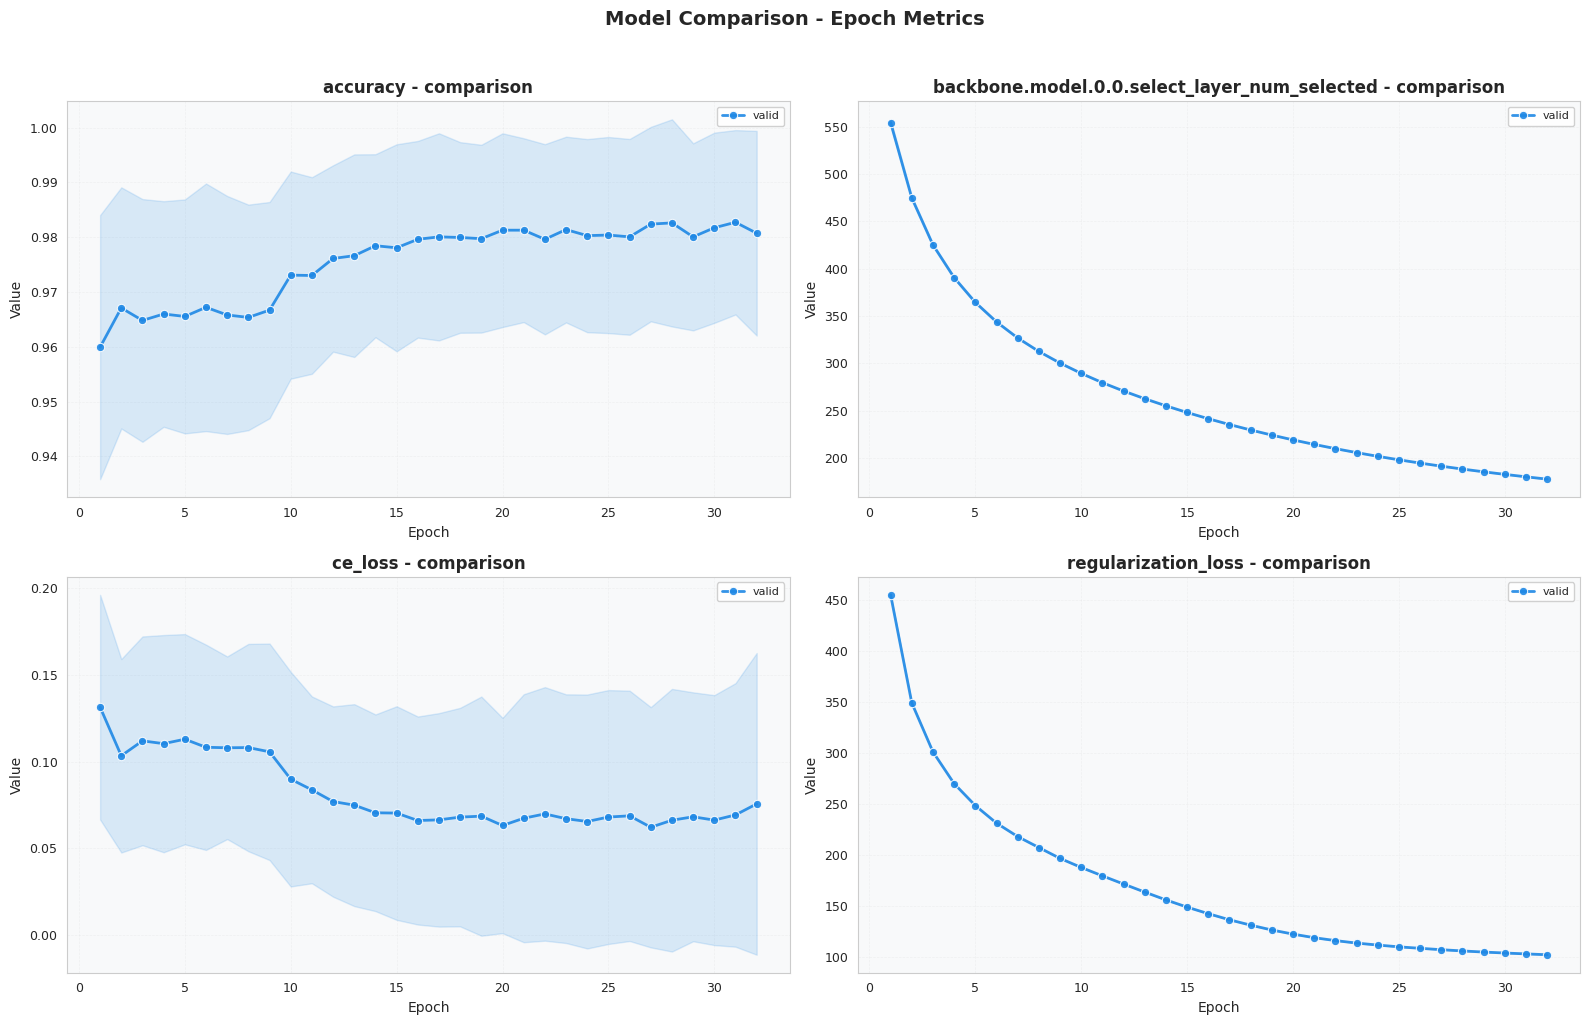

test accuracy: 0.9802945859872612 


In [28]:
model = ClassificationFeatureSelectionWrapper(
    backbone=FeedForwardNetwork(
        in_features=784,
        hidden_dim=128,
        out_features=10,
        num_layers=3,
        activation_class=nn.ReLU,
        norm_class=nn.BatchNorm1d,
        dropout=0.05
    ),
    lambda_coef=1e-3,
    feature_selection_layers_substring="0.0",
    criterion=nn.CrossEntropyLoss()
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr = 1e-3)

metrics = train(
    model,
    optimizer,
    train_loader,
    val_loader,
    device,
    num_epochs=32
)

compare_epoch_metrics(
    metrics_list=[metrics[2]],
    metrics_per_epoch_list=[metrics[3]],
    names=['valid']
)

test_metrics = evaluate(
    model,
    test_loader,
    device
)

print(f'test accuracy: {np.mean(test_metrics["accuracy"])} ')

#### Extract ids of selected pixels (features) to use

In [32]:
mask = ((model.backbone.model[0][0].select_layer.mu).to(torch.float) > 0.0)
keep_ids = torch.where(mask)[0]
print(f'num selected features: {len(keep_ids)}')

num selected features: 100


#### Use SkipIdxDataloader to select only "important" pixels

  0%|          | 0/32 [00:00<?, ?it/s]

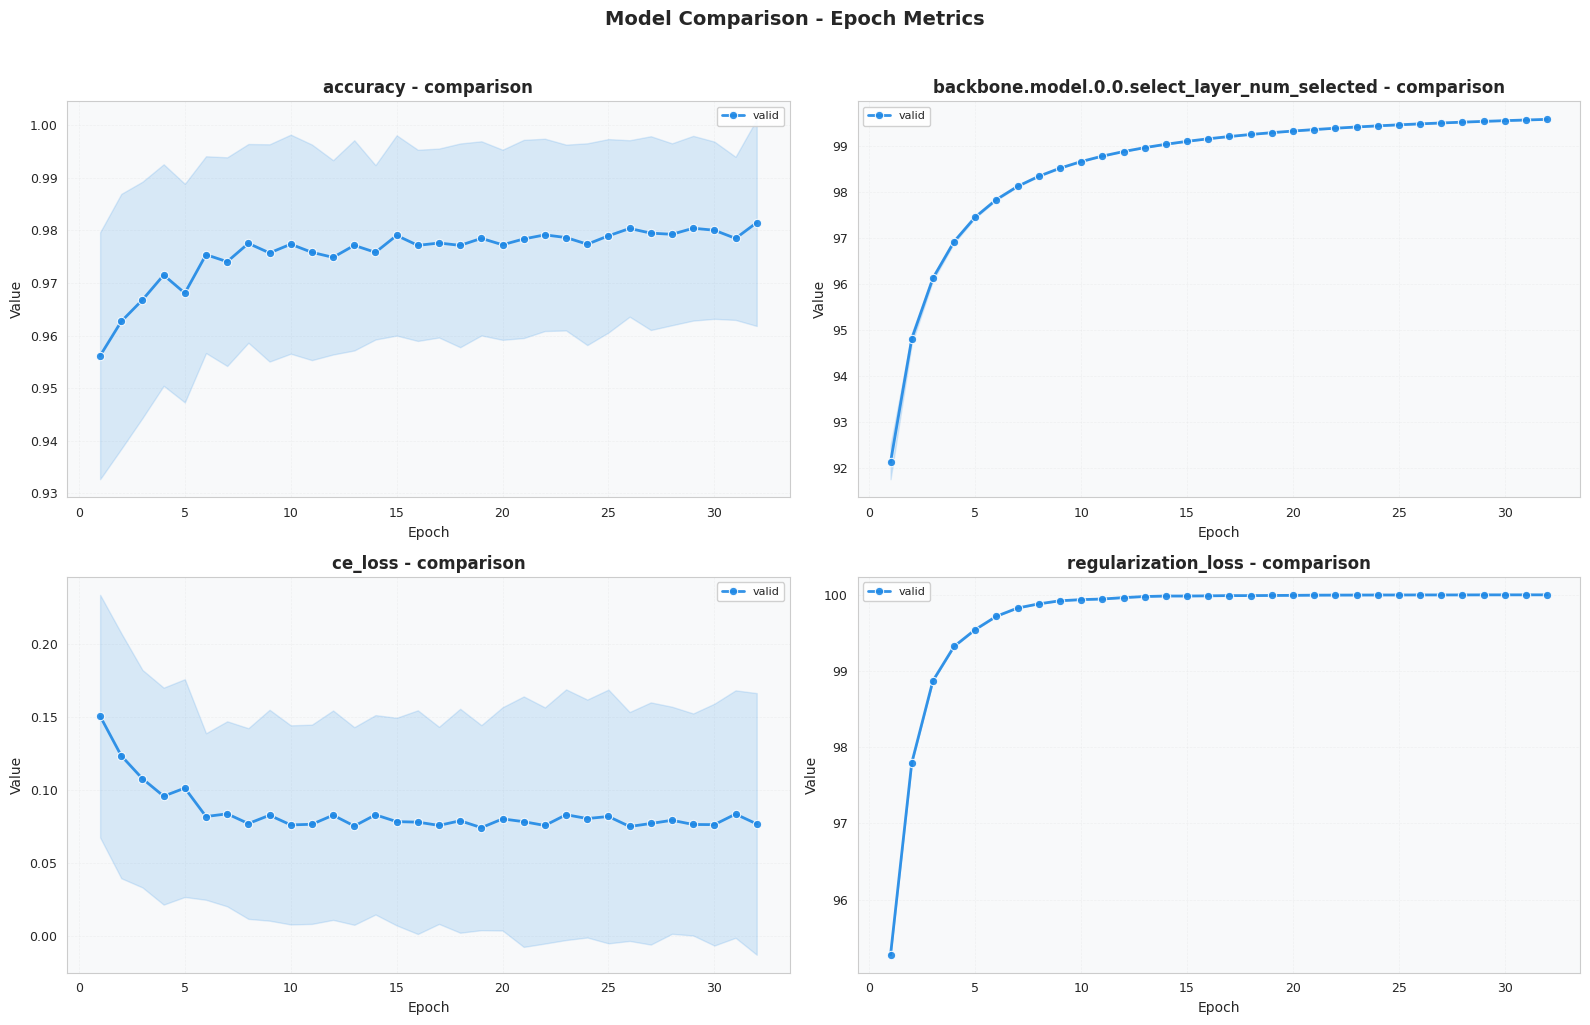

test accuracy: 0.979796974522293 


In [34]:
model = ClassificationFeatureSelectionWrapper(
    backbone=FeedForwardNetwork(
        in_features=len(keep_ids),
        hidden_dim=128,
        out_features=10,
        num_layers=3,
        activation_class=nn.ReLU,
        norm_class=nn.BatchNorm1d,
        dropout=0.05
    ),
    lambda_coef=0.0,
    feature_selection_layers_substring="0.0",
    criterion=nn.CrossEntropyLoss()
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr = 3e-3)

metrics = train(
    model,
    optimizer,
    SkipIdxDataloader(train_loader, keep_ids.to('cpu')),
    SkipIdxDataloader(val_loader, keep_ids.to('cpu')),
    device,
    num_epochs=32
)

compare_epoch_metrics(
    metrics_list=[metrics[2]],
    metrics_per_epoch_list=[metrics[3]],
    names=['valid']
)

test_metrics = evaluate(
    model,
    SkipIdxDataloader(test_loader, keep_ids.to('cpu')),
    device
)

print(f'test accuracy: {np.mean(test_metrics["accuracy"])} ')

#### Visualize selected pixels

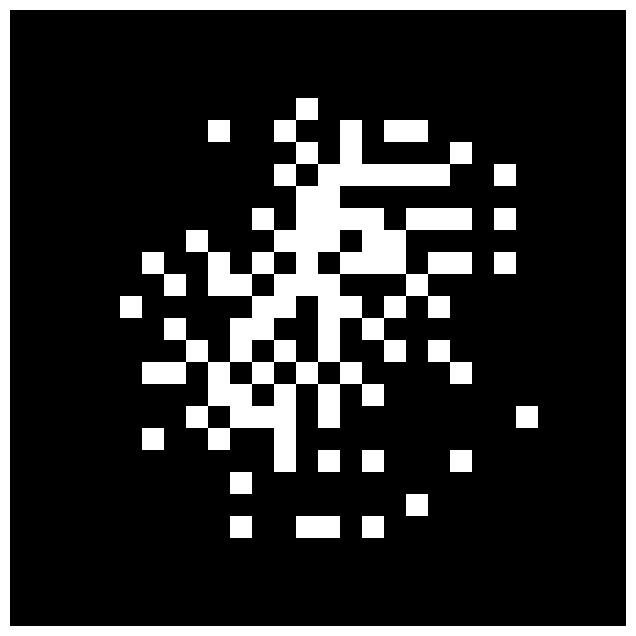

In [35]:
import matplotlib.pyplot as plt

mask = mask.reshape(1, 28, 28).squeeze()
plt.imshow(mask.cpu().detach().numpy(), cmap='gray')  # Use 'gray' colormap for grayscale images
plt.axis('off')  # Optional: remove axes
plt.show()